# 02. LangGraph 설계 원칙

> 그래프를 어떻게 쪼개야 디버깅·재실행·HITL이 쉬워질까요? 5단계 설계 방법론과 노드 분해 원칙을 따라가며 흔한 안티패턴을 미리 차단해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **5단계 구현 방법론**(워크플로우 매핑 → 타입 식별 → 상태 설계 → 노드 구현 → 엣지 연결)을 적용해서 LangGraph 앱을 체계적으로 설계할 수 있어요
2. **노드 분해 원칙**(단일 책임)을 이해하고, 스트리밍·체크포인트·디버깅에 유리한 구조로 그래프를 설계할 수 있어요
3. **4가지 에러 유형**(Transient / LLM-recoverable / User-fixable / Unexpected)별로 적절한 처리 전략을 선택할 수 있어요
4. **안티패턴**(상태에 포맷된 텍스트 저장, 거대 단일 노드, @task 없는 사이드 이펙트 등)을 식별하고 올바른 패턴으로 리팩터링할 수 있어요

## 사전 지식

- Part 02에서 배운 `StateGraph`, `Node`, `Edge`, `START/END`, `add_messages` reducer
- Part 03-01에서 배운 7가지 패턴(Augmented LLM, Prompt Chaining, Parallelization 등)
- `InMemorySaver`, `interrupt()`, `Command` 기본 사용법 (Part 02-07, 02-08)

## LangGraph 설계 원칙이란?

LangGraph로 에이전트를 만들 때 가장 큰 질문은 **"어떻게 설계해야 하는가?"** 예요.
코드를 바로 쓰기 전에 몇 가지 핵심 원칙을 이해하면 유지보수하기 쉽고 안정적인 그래프를 만들 수 있어요.

### 왜 설계 원칙이 중요한가요?

집을 짓는다고 상상해보세요. 설계도 없이 벽돌부터 쌓으면 나중에 벽을 허물고 다시 지어야 해요. 소프트웨어도 마찬가지예요. **5분의 설계가 5시간의 디버깅을 절약**해요. 특히 LangGraph는 노드 분해, 상태 설계, 에러 처리 등 의사결정이 많아서 체계적인 접근이 더욱 중요해요.

이 노트북에서는 **EmailAgent**라는 예제를 통해 설계 원칙을 단계적으로 살펴볼게요.
EmailAgent는 이메일을 받아 분류하고, 관련 정보를 검색하고, 사람 검토 후 답장을 전송하는 시스템이에요.

```mermaid
flowchart TD
    A(["시작"]) --> B["이메일 분류<br/>classify_email"]
    B --> C{"분류 결과"}
    C -->|"중요"| D["컨텍스트 검색<br/>retrieve_context"]
    C -->|"스팸"| Z(["종료"])
    D --> E["초안 작성<br/>draft_response"]
    E --> F["인간 검토<br/>human_review"]
    F -->|"승인"| G["이메일 전송<br/>send_email"]
    F -->|"수정 요청"| E
    G --> Z

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef human fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,D,E,G process
    class C,F decision
    class Z output
```

| 설계 원칙 | 핵심 내용 | 비유 |
|-----------|----------|------|
| **5단계 방법론** | 워크플로우 매핑 -> 타입 식별 -> 상태 설계 -> 노드 구현 -> 엣지 연결 | 건축 설계도 그리기 |
| **노드 분해** | 단일 책임 원칙, 스트리밍/체크포인트/디버깅에 최적화 | 레고 블록처럼 쪼개기 |
| **상태 설계** | raw data 저장, formatted text 금지, reducer 선택 | 데이터베이스 스키마 설계 |
| **에러 처리** | 4가지 유형별 전략 (Transient/LLM-recoverable/User-fixable/Unexpected) | 병원 응급실 분류 (트리아지) |
| **안티패턴** | 피해야 할 패턴과 올바른 대안 | 흔한 실수 목록 |

> 🔑 **핵심 개념**: 좋은 LangGraph 설계는 **"그래프를 어떻게 분해할 것인가"** 에서 출발해요. 노드를 너무 크게 만들면 디버깅이 어렵고, 너무 잘게 쪼개면 복잡해져요. 각 노드가 **하나의 명확한 책임**을 갖도록 설계하는 것이 핵심이에요.

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키를 읽어와요)
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# LangSmith 추적 설정 (학습 중 그래프 실행 과정을 추적할 수 있어요)
import os
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Part03-DesignPrinciples"

In [3]:
# LangChain V1 모델 초기화
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델 옵션:
#   - Anthropic: "anthropic:claude-sonnet-4-5"
#   - Google Gemini: "google_genai:gemini-2.0-flash"
model = init_chat_model("openai:gpt-4o-mini")
# 모델 초기화 완료

## 1. 5단계 구현 방법론

LangGraph 앱을 만들 때 **체계적인 순서**를 따르면 설계 실수를 줄일 수 있어요.
아래 5단계를 EmailAgent 예제에 적용해볼게요.

```mermaid
flowchart LR
    S1["1단계<br>워크플로우 매핑"] --> S2["2단계<br>타입 식별"]
    S2 --> S3["3단계<br>상태 설계"]
    S3 --> S4["4단계<br>노드 구현"]
    S4 --> S5["5단계<br>엣지 연결"]

    classDef step fill:#cce5ff,stroke:#007bff,color:#004085
    class S1,S2,S3,S4,S5 step
```

### 1단계: 워크플로우 매핑

먼저 시스템이 해야 할 **작업의 흐름**을 글로 정리해요.
- 이메일을 받아서 스팸인지 중요 이메일인지 분류해요
- 중요 이메일이면 관련 문서를 검색해서 컨텍스트를 구성해요
- 검색 결과를 바탕으로 답장 초안을 작성해요
- 사람이 검토하고 승인하거나 수정을 요청해요
- 승인된 초안을 이메일로 전송해요

### 2단계: 타입 식별

각 단계에서 **어떤 데이터**가 흐르는지 파악해요.
- 입력: 이메일 원문 (str)
- 분류 결과: "important" 또는 "spam" (str)
- 검색된 컨텍스트: 문서 목록 (list[str])
- 초안: 답장 텍스트 (str)
- 인간 피드백: 승인 여부 + 수정 의견 (bool + str)

> 🎯 **강의 포인트**: 타입을 먼저 식별하면 상태(State)를 설계할 때 어떤 필드가 필요한지 명확해져요. 이 단계를 건너뛰면 나중에 상태에 불필요한 필드가 늘어나거나, 필요한 데이터가 없어서 그래프를 수정해야 해요.

### 3단계: 상태 설계

상태(State)는 그래프 전체에서 공유되는 **메모리**예요. 설계 시 두 가지 핵심 규칙이 있어요.

**규칙 1: raw data를 저장하세요. formatted text는 금지예요.**

```python
# 나쁜 예 - 포맷된 텍스트를 상태에 저장하면 안 돼요
class BadState(TypedDict):
    email_summary: str  # "발신자: kim@example.com\n제목: 안녕하세요\n내용: ..."

# 좋은 예 - 구조화된 raw data를 저장해요
class GoodState(TypedDict):
    email_sender: str    # "kim@example.com"
    email_subject: str   # "안녕하세요"
    email_body: str      # "..."
```

**규칙 2: 리스트 필드는 reducer를 명시하세요.**

- 메시지 히스토리처럼 **누적**해야 하면 `Annotated[list, operator.add]`
- 매번 **덮어써야** 하면 reducer 없이 `list[str]`

> ⚠️ **자주 하는 실수**: 상태에 포맷된 텍스트를 저장하면 다음 노드에서 다시 파싱해야 해요. 이 과정에서 오류가 발생하기 쉽고, 코드가 복잡해져요. 항상 구조화된 원본 데이터를 저장하세요.

In [4]:
# ---------------------------------------------------
# 3단계: EmailAgent 상태 설계
# raw data 저장 원칙을 따른 올바른 상태 정의예요
# ---------------------------------------------------
from typing import TypedDict, Optional

class EmailState(TypedDict):
    # --- 입력 데이터 (raw data) ---
    email_sender: str        # 발신자 이메일 주소
    email_subject: str       # 이메일 제목
    email_body: str          # 이메일 본문

    # --- 처리 결과 (raw data) ---
    classification: str      # "important" 또는 "spam"
    context_docs: list[str]  # 검색된 관련 문서 목록
    draft: str               # 작성된 답장 초안

    # --- 인간 검토 결과 ---
    human_approved: bool     # True: 승인 / False: 수정 요청
    human_feedback: str      # 수정 요청 시 피드백 내용

    # --- 최종 결과 ---
    sent: bool               # 전송 완료 여부

# EmailState 설계 완료!
print("상태 필드:", list(EmailState.__annotations__.keys()))

상태 필드: ['email_sender', 'email_subject', 'email_body', 'classification', 'context_docs', 'draft', 'human_approved', 'human_feedback', 'sent']


### 4단계: 노드 구현

각 노드는 **단일 책임 원칙**을 따라야 해요. 하나의 노드가 여러 가지 일을 동시에 하면:
- 어느 부분에서 에러가 났는지 파악하기 어려워요
- 특정 단계만 스트리밍으로 확인하기 어려워요
- 체크포인트 저장 시 중간 상태를 활용하기 어려워요

> 💡 **실무 팁**: 노드 하나가 **10초 이상** 걸린다면 더 작게 쪼개는 것을 고려해 보세요. 체크포인트는 노드 단위로 저장되므로, 노드가 클수록 실패 시 재시작 비용이 커요.

In [5]:
# ---------------------------------------------------
# 4단계: EmailAgent 노드 구현
# 각 노드는 단일 책임(하나의 역할)만 수행해요
# ---------------------------------------------------
from langchain.messages import HumanMessage, SystemMessage

def classify_email(state: EmailState) -> dict:
    """노드 1: 이메일을 분류해요 (important / spam)."""
    response = model.invoke([
        SystemMessage(content="""이메일을 분류하세요. 반드시 'important' 또는 'spam' 중 하나만 응답하세요.
업무 관련, 고객 문의, 협력 제안 등은 important입니다.
광고, 프로모션, 의심스러운 내용은 spam입니다."""),
        HumanMessage(content=f"제목: {state['email_subject']}\n본문: {state['email_body']}")
    ])
    raw = response.content.strip().lower()
    # LLM 응답에서 분류 결과를 안전하게 추출해요
    classification = "important" if "important" in raw else "spam"
    print(f"[분류] 이메일 분류 결과: {classification}")
    return {"classification": classification}


def retrieve_context(state: EmailState) -> dict:
    """노드 2: 이메일 관련 문서를 검색해요 (교육용 더미 구현)."""
    # 실제 구현에서는 벡터 DB나 검색 API를 호출해요
    # 여기서는 이메일 주제에 맞는 더미 컨텍스트를 반환해요
    dummy_docs = [
        f"관련 문서 1: {state['email_subject']}에 관한 이전 대화 기록",
        f"관련 문서 2: {state['email_sender']}님과의 이전 이메일 스레드",
        "관련 문서 3: 회사 표준 이메일 답변 가이드라인",
    ]
    print(f"[검색] {len(dummy_docs)}개 문서 검색 완료")
    return {"context_docs": dummy_docs}


def draft_response(state: EmailState) -> dict:
    """노드 3: 컨텍스트를 바탕으로 답장 초안을 작성해요."""
    context_text = "\n".join(state["context_docs"])
    response = model.invoke([
        SystemMessage(content=f"""당신은 전문 이메일 작성 어시스턴트예요.
다음 컨텍스트를 참고해서 이메일 답장 초안을 작성해주세요.

참고 문서:
{context_text}"""),
        HumanMessage(content=f"""
발신자: {state['email_sender']}
제목: {state['email_subject']}
내용: {state['email_body']}

위 이메일에 대한 전문적이고 친절한 답장을 작성해주세요.
""")
    ])
    # 이전 피드백이 있으면 반영했다는 로그를 출력해요
    if state.get("human_feedback"):
        print(f"[초안] 피드백 반영하여 재작성: {state['human_feedback'][:50]}...")
    else:
        print(f"[초안] 초안 작성 완료 ({len(response.content)}자)")
    return {"draft": response.content}


def send_email(state: EmailState) -> dict:
    """노드 4: 승인된 초안을 이메일로 전송해요 (교육용 더미 구현)."""
    # 실제 구현에서는 SMTP나 이메일 API를 사용해요
    print(f"[전송] {state['email_sender']}님에게 이메일 전송 완료!")
    print(f"[전송] 전송된 내용 미리보기: {state['draft'][:100]}...")
    return {"sent": True}


# 노드 구현 완료!

### 5단계: 엣지 연결

마지막으로 노드들을 연결해서 그래프를 완성해요.
조건에 따라 다른 경로로 가야 할 때는 `add_conditional_edges`를 사용해요.

In [6]:
# ---------------------------------------------------
# 5단계: 엣지 연결 - 전체 EmailAgent 그래프 조립
# ---------------------------------------------------
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt

def route_by_classification(state: EmailState) -> Literal["retrieve_context", "end"]:
    """분류 결과에 따라 중요 이메일은 처리, 스팸은 종료해요."""
    if state["classification"] == "important":
        return "retrieve_context"
    return "end"  # 스팸은 더 처리하지 않아요


def human_review_node(state: EmailState) -> dict:
    """인간 검토 노드: interrupt()를 사용해서 실행을 일시 중단해요.
    
    interrupt() 사용 규칙:
    1. 노드의 '처음'에 배치해요
    2. try/except 안에 넣으면 안 돼요
    3. 순서 일관성을 유지해야 해요
    """
    # interrupt()는 노드 처음에 배치해요 - 이것이 권장 패턴이에요
    # 사람에게 초안을 보여주고 승인 여부를 물어봐요
    human_input = interrupt({
        "action": "review_draft",
        "draft": state["draft"],
        "message": "아래 초안을 검토해주세요. 승인하시면 'approve', 수정이 필요하면 피드백을 입력해주세요."
    })

    # 인간의 응답을 처리해요
    if human_input == "approve" or human_input is True:
        print(f"[인간 검토] 초안 승인")
        return {"human_approved": True, "human_feedback": ""}
    else:
        print(f"[인간 검토] 수정 요청: {str(human_input)[:50]}...")
        return {"human_approved": False, "human_feedback": str(human_input)}


def route_after_review(state: EmailState) -> Literal["send_email", "draft_response"]:
    """인간 검토 결과에 따라 전송 또는 재작성으로 분기해요."""
    if state["human_approved"]:
        return "send_email"   # 승인: 전송
    return "draft_response"   # 수정 요청: 재작성


# 체크포인터: 인간 검토(interrupt) 사용을 위해 필수예요
checkpointer = InMemorySaver()

# 그래프 조립
email_graph = StateGraph(EmailState)

# 노드 추가
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("retrieve_context", retrieve_context)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("human_review", human_review_node)
email_graph.add_node("send_email", send_email)

# 엣지 연결
email_graph.add_edge(START, "classify_email")
# 분류 후 조건부 분기: important → 검색, spam → 종료
email_graph.add_conditional_edges(
    "classify_email",
    route_by_classification,
    {"retrieve_context": "retrieve_context", "end": END}
)
email_graph.add_edge("retrieve_context", "draft_response")
email_graph.add_edge("draft_response", "human_review")
# 인간 검토 후 조건부 분기: 승인 → 전송, 수정 → 재작성
email_graph.add_conditional_edges(
    "human_review",
    route_after_review,
    {"send_email": "send_email", "draft_response": "draft_response"}
)
email_graph.add_edge("send_email", END)

# 그래프 컴파일 (체크포인터 포함 - interrupt에 필요)
email_app = email_graph.compile(checkpointer=checkpointer)
# EmailAgent 그래프 구성 완료!

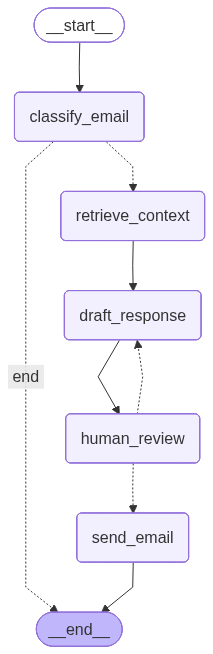

In [7]:
# 그래프 흐름: START → classify_email → (important) retrieve_context → draft_response → human_review → send_email → END
#                              → (spam) END
# human_review 노드에서 interrupt()가 발생하고, Command(resume=...)로 재개해요
# ---------------------------------------------------
# EmailAgent 그래프 구조 시각화
# ---------------------------------------------------
from IPython.display import Image, display

display(Image(email_app.get_graph().draw_mermaid_png()))

In [8]:
# ---------------------------------------------------
# EmailAgent 실행: 스팸 이메일 처리 (중단 없이 바로 종료)
# ---------------------------------------------------
import uuid

# 스레드 ID: 체크포인터가 상태를 구분하는 식별자예요
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

# 스팸 이메일 입력
spam_email = {
    "email_sender": "promo@spam-example.com",
    "email_subject": "[광고] 지금 당장 클릭! 100만원 당첨!",
    "email_body": "축하합니다! 당신이 선택되었습니다. 지금 링크를 클릭하세요.",
    "classification": "",
    "context_docs": [],
    "draft": "",
    "human_approved": False,
    "human_feedback": "",
    "sent": False
}

# === 스팸 이메일 처리 ===
result = email_app.invoke(spam_email, config)
print(f"\n결과: 분류={result['classification']}, 전송={result['sent']}")

[분류] 이메일 분류 결과: spam

결과: 분류=spam, 전송=False


In [9]:
# ---------------------------------------------------
# EmailAgent 실행: 중요 이메일 처리 (인간 검토 포함)
# interrupt()에서 멈추고 Command로 재개하는 패턴이에요
# ---------------------------------------------------
from langgraph.types import Command

# 새 스레드로 중요 이메일 처리
thread_id_2 = str(uuid.uuid4())
config_2 = {"configurable": {"thread_id": thread_id_2}}

important_email = {
    "email_sender": "client@bigcompany.com",
    "email_subject": "LangGraph 교육 프로그램 문의",
    "email_body": "안녕하세요. 저희 팀에 LangGraph 교육을 제공해주실 수 있는지 문의드립니다. 팀 규모는 10명이고, 2주 과정을 원합니다.",
    "classification": "",
    "context_docs": [],
    "draft": "",
    "human_approved": False,
    "human_feedback": "",
    "sent": False
}

# === 중요 이메일 처리 (1단계: 초안 작성까지) ===
# interrupt()가 발생하면 실행이 여기서 멈춰요
result_partial = email_app.invoke(important_email, config_2)

# --- interrupt()에서 멈췄어요 ---
print(f"작성된 초안 미리보기:")
print(result_partial.get("draft", "초안 없음")[:300])

[분류] 이메일 분류 결과: important
[검색] 3개 문서 검색 완료
[초안] 초안 작성 완료 (480자)
작성된 초안 미리보기:
제목: LangGraph 교육 프로그램 요청에 대한 답변

안녕하세요, [고객님 성함]님.

저희 LangGraph 교육 프로그램에 관심을 가져주셔서 감사합니다. 팀 규모와 요청하신 2주 과정에 대한 정보를 확인하였습니다. 

저희는 귀하의 팀을 위한 맞춤형 교육 프로그램을 제공할 수 있으며, 교육 내용과 일정을 조정하여 귀사의 니즈에 최적화할 수 있습니다. 10명의 팀원이 함께 참여하는 교육 프로그램에 대해 더욱 자세한 정보를 제공하기 위해 몇 가지 질문을 드리고 싶습니다:

1. 교육에서 다루고 싶은 특정 주제나 기술이 있으신가


In [10]:
# ---------------------------------------------------
# EmailAgent 재개: Command(resume=...)로 인간 검토 결과 전달
# "approve"를 전달하면 바로 전송, 피드백 텍스트를 전달하면 재작성
# ---------------------------------------------------

# === 중요 이메일 처리 (2단계: 인간 검토 후 재개) ===

# Command(resume=...) 로 interrupt에 응답을 전달해요
# "approve"를 보내면 승인, 다른 텍스트를 보내면 수정 피드백으로 처리돼요
final_result = email_app.invoke(
    Command(resume="approve"),  # 초안 승인
    config_2
)

print(f"\n=== 최종 결과 ===")
print(f"분류: {final_result['classification']}")
print(f"인간 승인: {final_result['human_approved']}")
print(f"전송 완료: {final_result['sent']}")

[인간 검토] 초안 승인
[전송] client@bigcompany.com님에게 이메일 전송 완료!
[전송] 전송된 내용 미리보기: 제목: LangGraph 교육 프로그램 요청에 대한 답변

안녕하세요, [고객님 성함]님.

저희 LangGraph 교육 프로그램에 관심을 가져주셔서 감사합니다. 팀 규모와 요청하...

=== 최종 결과 ===
분류: important
인간 승인: True
전송 완료: True


## 2. 에러 처리 전략

### 왜 에러 유형을 구분해야 하나요?

병원 응급실에서 모든 환자를 같은 방식으로 치료하지 않는 것처럼, 에러도 **유형에 따라 다른 전략**이 필요해요. 네트워크가 잠깐 끊긴 거라면 재시도하면 되지만, 사용자가 입력을 잘못한 거라면 재시도해도 똑같이 실패해요.

LangGraph에서 에러는 4가지 유형으로 나뉘어요. 각 유형에 맞는 처리 전략이 달라요.

```mermaid
flowchart TD
    ERR["에러 발생"] --> T1["Transient<br/>일시적 오류"]
    ERR --> T2["LLM-recoverable<br/>LLM으로 복구 가능"]
    ERR --> T3["User-fixable<br/>사용자가 수정 가능"]
    ERR --> T4["Unexpected<br/>예상치 못한 오류"]

    T1 --> S1["RetryPolicy로<br/>자동 재시도"]
    T2 --> S2["오류 피드백을 상태에 저장<br/>-> LLM 노드로 루프백"]
    T3 --> S3["interrupt()로 중단<br/>-> 사용자 입력 대기"]
    T4 --> S4["예외를 그대로 전파<br/>-> 상위에서 처리"]

    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef strategy fill:#d4edda,stroke:#28a745,color:#155724

    class ERR,T1,T2,T3,T4 error
    class S1,S2,S3,S4 strategy
```

| 에러 유형 | 예시 | 처리 전략 | 비유 |
|-----------|------|-----------|------|
| **Transient** | API 타임아웃, 일시적 네트워크 오류 | `RetryPolicy` 자동 재시도 | 전화가 안 터져서 재다이얼 |
| **LLM-recoverable** | 잘못된 JSON 형식, 형식 오류 | 오류를 상태에 담아 LLM 노드로 루프백 | 보고서 양식이 틀려서 다시 작성 요청 |
| **User-fixable** | 모호한 입력, 권한 부족 | `interrupt()`로 사용자에게 재입력 요청 | 서류 미비로 창구 재방문 요청 |
| **Unexpected** | 코드 버그, 데이터 오염 | 예외 전파, 상위에서 처리 | 원인 불명 고장 -> 전문가 호출 |

> 🔑 **핵심 개념**: 에러를 잡아서 무조건 감추는 것은 나쁜 패턴이에요. **각 에러 유형에 맞는 전략**을 쓰면 시스템이 더 강건(robust)해요. Unexpected 에러는 숨기지 말고 전파해서 개발자가 알 수 있게 해야 해요.

In [11]:
# ---------------------------------------------------
# 에러 유형 1: Transient - RetryPolicy로 자동 재시도
# 네트워크 오류, API 타임아웃처럼 잠깐 기다리면 해결되는 오류에 사용해요
# ---------------------------------------------------
from langgraph.types import RetryPolicy
from langgraph.graph import StateGraph
from typing import TypedDict

class RetryState(TypedDict):
    attempt_count: int  # 시도 횟수 (테스트용)
    result: str

# 처음 2번은 실패하고 3번째에 성공하는 더미 함수예요
_retry_call_count = 0

def flaky_api_call(state: RetryState) -> dict:
    """불안정한 외부 API를 호출하는 노드예요."""
    global _retry_call_count
    _retry_call_count += 1
    print(f"  API 호출 시도 #{_retry_call_count}")

    # 처음 2번은 실패 (Transient 오류 시뮬레이션)
    if _retry_call_count < 3:
        raise ConnectionError(f"API 일시 오류 (시도 #{_retry_call_count})")

    return {"result": "API 호출 성공!", "attempt_count": _retry_call_count}

# RetryPolicy 설정:
# - max_attempts: 최대 재시도 횟수
# - retry_on: 어떤 예외에서 재시도할지 (ConnectionError만 재시도)
retry_policy = RetryPolicy(
    max_attempts=5,
    retry_on=(ConnectionError,)  # ConnectionError에서만 재시도해요
)

# 그래프 구성 - 노드에 RetryPolicy를 직접 전달해요
retry_graph = StateGraph(RetryState)
retry_graph.add_node(
    "api_call",
    flaky_api_call,
    retry=retry_policy  # RetryPolicy를 노드에 적용해요
)
retry_graph.add_edge(START, "api_call")
retry_graph.add_edge("api_call", END)

retry_app = retry_graph.compile()

# RetryPolicy 테스트 시작:
_retry_call_count = 0  # 카운터 초기화
result = retry_app.invoke({"attempt_count": 0, "result": ""})
print(f"\n최종 결과: {result['result']} (총 {result['attempt_count']}번 시도)")

  API 호출 시도 #1
  API 호출 시도 #2
  API 호출 시도 #3

최종 결과: API 호출 성공! (총 3번 시도)


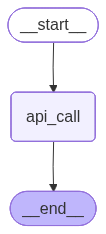

In [12]:
# 그래프 흐름: START → call_api → END
# call_api 노드: API를 호출하며, RetryPolicy로 transient 오류 시 자동 재시도해요
from IPython.display import Image, display
display(Image(retry_app.get_graph().draw_mermaid_png()))

In [13]:
# ---------------------------------------------------
# 에러 유형 2: LLM-recoverable - 오류 피드백 루프백
# LLM이 잘못된 형식으로 응답했을 때, 오류 메시지를 다시 LLM에게 전달해요
# ---------------------------------------------------
import json

class ParseState(TypedDict):
    raw_input: str       # 분석할 원본 텍스트
    llm_output: str      # LLM이 생성한 원본 응답
    parsed_data: dict    # 파싱된 결과
    parse_error: str     # 파싱 오류 메시지 (있으면 재시도)
    retry_count: int     # 재시도 횟수

def generate_json(state: ParseState) -> dict:
    """LLM에게 JSON 형식으로 응답을 요청해요.
    이전 파싱 오류가 있으면 오류 내용을 포함해서 재요청해요.
    """
    system_msg = """주어진 텍스트에서 정보를 추출해서 반드시 아래 형식의 JSON만 응답하세요.
다른 텍스트 없이 JSON만 출력해야 해요:
{"name": "이름", "email": "이메일", "topic": "주제"}"""

    user_content = f"텍스트: {state['raw_input']}"

    # 이전 오류가 있으면 오류 내용을 포함해서 재요청해요
    if state.get("parse_error"):
        user_content += f"\n\n이전 응답이 잘못되었어요: {state['parse_error']}\n반드시 올바른 JSON만 응답해주세요."
        print(f"[JSON 생성] 재시도 #{state['retry_count']} (오류: {state['parse_error'][:40]}...)")
    else:
        print(f"[JSON 생성] 첫 번째 시도")

    response = model.invoke([
        SystemMessage(content=system_msg),
        HumanMessage(content=user_content)
    ])
    return {"llm_output": response.content, "retry_count": state.get("retry_count", 0) + 1}


def parse_json_output(state: ParseState) -> dict:
    """LLM 응답을 JSON으로 파싱해요. 실패 시 오류를 상태에 저장해요."""
    try:
        # JSON 블록 추출 (```json ... ``` 형식도 처리해요)
        raw = state["llm_output"].strip()
        if "```" in raw:
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        parsed = json.loads(raw)
        print(f"[파싱] 성공: {parsed}")
        return {"parsed_data": parsed, "parse_error": ""}  # 오류 초기화
    except json.JSONDecodeError as e:
        error_msg = f"JSON 파싱 실패: {str(e)} | 원본: {state['llm_output'][:50]}"
        print(f"[파싱] 실패 - {error_msg}")
        return {"parsed_data": {}, "parse_error": error_msg}


def route_after_parse(state: ParseState) -> str:
    """파싱 성공 여부와 재시도 횟수에 따라 분기해요."""
    if state["parsed_data"]:        # 파싱 성공
        return "success"
    if state.get("retry_count", 0) >= 3:  # 최대 3회 재시도
        print(f"[라우터] 최대 재시도 횟수 도달, 종료해요")
        return "give_up"
    return "retry"  # 오류 피드백과 함께 LLM 재호출


# 그래프 구성
parse_graph = StateGraph(ParseState)
parse_graph.add_node("generate", generate_json)
parse_graph.add_node("parse", parse_json_output)
parse_graph.add_edge(START, "generate")
parse_graph.add_edge("generate", "parse")
parse_graph.add_conditional_edges(
    "parse",
    route_after_parse,
    {"success": END, "give_up": END, "retry": "generate"}  # retry 시 다시 LLM 호출
)

parse_app = parse_graph.compile()

# === LLM-recoverable 오류 처리 테스트 ===
result = parse_app.invoke({
    "raw_input": "김철수님의 이메일은 kim@example.com이고, LangGraph 교육에 관심이 있어요.",
    "llm_output": "",
    "parsed_data": {},
    "parse_error": "",
    "retry_count": 0
})

print(f"\n최종 파싱 결과: {result['parsed_data']}")

[JSON 생성] 첫 번째 시도
[파싱] 성공: {'name': '김철수', 'email': 'kim@example.com', 'topic': 'LangGraph 교육'}

최종 파싱 결과: {'name': '김철수', 'email': 'kim@example.com', 'topic': 'LangGraph 교육'}


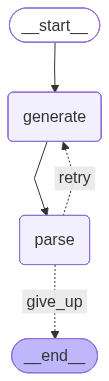

In [14]:
# 그래프 흐름: START → parse → validate → parse(루프) 또는 END
# parse 노드: LLM 응답을 파싱해요
# validate 노드: 파싱 결과를 검증하고, 실패 시 오류 메시지와 함께 parse로 루프백해요
display(Image(parse_app.get_graph().draw_mermaid_png()))

## 3. Command: 상태 업데이트 + 라우팅 동시 처리

`Command`는 노드에서 **상태를 업데이트하면서 동시에 다음 노드를 지정**할 수 있는 강력한 기능이에요.
일반 `add_conditional_edges`와 달리, 노드 내부에서 다음 이동 경로를 동적으로 결정할 수 있어요.

```mermaid
flowchart LR
    N1["노드 A"] -->|"Command(update=..., goto='B')"| N2["노드 B"]
    N1 -->|"Command(update=..., goto='C')"| N3["노드 C"]

    classDef node fill:#cce5ff,stroke:#007bff,color:#004085
    class N1,N2,N3 node
```

> 🔑 **핵심 개념**: `Command`는 두 가지 역할을 동시에 해요:
> 1. `update`: 상태 필드를 업데이트해요 (`return {"field": value}`와 동일)
> 2. `goto`: 다음으로 이동할 노드를 직접 지정해요
>
> `interrupt()`를 사용한 후 `Command(resume=...)`로 응답하는 패턴도 이 개념의 연장이에요.

> 💡 **실무 팁**: `Command`는 노드 함수가 상태와 라우팅 로직을 **모두 알고 있어야 할 때** 유용해요. 단, 코드 가독성을 위해 라우팅 로직이 복잡하다면 `add_conditional_edges`를 별도로 사용하는 것이 더 명확할 수 있어요.

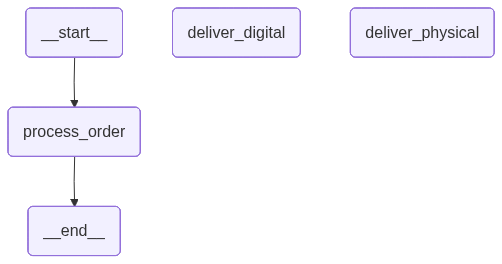

In [15]:
# ---------------------------------------------------
# Command: 상태 업데이트 + 라우팅을 한 번에 처리하는 패턴
# 노드가 다음 목적지를 직접 결정해요
# ---------------------------------------------------
from langgraph.types import Command
from typing import Union

class OrderState(TypedDict):
    order_id: str
    item_type: str    # "digital" 또는 "physical"
    status: str
    message: str

def process_order(state: OrderState) -> Command:
    """주문을 처리하고 Command로 상태 업데이트 + 다음 노드를 동시에 결정해요."""
    item_type = state["item_type"]
    print(f"[주문 처리] 주문 #{state['order_id']}, 상품 유형: {item_type}")

    if item_type == "digital":
        # Command로 상태 업데이트와 라우팅을 한 번에 처리해요
        return Command(
            update={"status": "processing", "message": "디지털 상품 처리 중"},
            goto="deliver_digital"   # 다음 노드를 직접 지정
        )
    else:
        return Command(
            update={"status": "processing", "message": "실물 상품 처리 중"},
            goto="deliver_physical"  # 다른 노드로 라우팅
        )

def deliver_digital(state: OrderState) -> dict:
    """디지털 상품 배달 노드예요."""
    print(f"[디지털 배달] 다운로드 링크 전송 완료")
    return {"status": "completed", "message": "다운로드 링크가 이메일로 전송되었어요"}

def deliver_physical(state: OrderState) -> dict:
    """실물 상품 배달 노드예요."""
    print(f"[실물 배달] 물류 시스템에 배송 요청")
    return {"status": "shipped", "message": "3-5일 내 배송 예정이에요"}

# 그래프 구성
order_graph = StateGraph(OrderState)
order_graph.add_node("process_order", process_order)
order_graph.add_node("deliver_digital", deliver_digital)
order_graph.add_node("deliver_physical", deliver_physical)

order_graph.add_edge(START, "process_order")
# Command를 사용하는 노드에서는 conditional_edges가 필요 없어요
order_graph.add_edge("deliver_digital", END)
order_graph.add_edge("deliver_physical", END)

order_app = order_graph.compile()
# 그래프 흐름: START → process_order → ship_digital/ship_physical → END
# process_order 노드: 주문 유형을 확인하고 Command로 배송 노드를 결정해요
# 조건부 분기: digital이면 ship_digital, physical이면 ship_physical로 이동해요
display(Image(order_app.get_graph().draw_mermaid_png()))

In [16]:
# ---------------------------------------------------
# Command 패턴 실행 테스트
# ---------------------------------------------------

# 디지털 상품 주문 테스트
# === 디지털 상품 주문 ===
digital_result = order_app.invoke({
    "order_id": "D-001",
    "item_type": "digital",
    "status": "",
    "message": ""
})
print(f"결과: {digital_result['status']} - {digital_result['message']}")

print()

# 실물 상품 주문 테스트
# === 실물 상품 주문 ===
physical_result = order_app.invoke({
    "order_id": "P-001",
    "item_type": "physical",
    "status": "",
    "message": ""
})
print(f"결과: {physical_result['status']} - {physical_result['message']}")

[주문 처리] 주문 #D-001, 상품 유형: digital
[디지털 배달] 다운로드 링크 전송 완료
결과: completed - 다운로드 링크가 이메일로 전송되었어요

[주문 처리] 주문 #P-001, 상품 유형: physical
[실물 배달] 물류 시스템에 배송 요청
결과: shipped - 3-5일 내 배송 예정이에요


## 4. 안티패턴과 올바른 패턴

실무에서 자주 보이는 잘못된 패턴과 올바른 대안을 살펴볼게요.

> 🎯 **강의 포인트**: 안티패턴은 당장 동작하지만 **나중에 문제가 생겨요**. 코드 리뷰에서 이런 패턴이 보이면 리팩터링 신호예요. 지금 몇 분 투자해서 올바른 패턴으로 바꾸면 나중에 몇 시간을 절약할 수 있어요.

In [17]:
# ---------------------------------------------------
# 안티패턴 1: 상태에 포맷된 텍스트 저장
# 왜 나쁜가: 다음 노드에서 파싱이 필요하고, 파싱 실패 시 전체가 망가져요
# ---------------------------------------------------

# 나쁜 예: 포맷된 텍스트를 상태에 저장해요
class BadProductState(TypedDict):
    product_info: str  # "이름: 노트북\n가격: 1500000\n재고: 50" 같은 형식

def bad_process_product(state: BadProductState) -> dict:
    """나쁜 예: 포맷된 텍스트를 파싱해야 해서 취약해요."""
    # 이 파싱 코드는 LLM 출력 형식이 조금만 바뀌어도 실패해요
    lines = state["product_info"].split("\n")
    try:
        name = lines[0].split(": ")[1]       # 파싱 실패 가능성
        price = int(lines[1].split(": ")[1])  # 파싱 실패 가능성
        return {"product_info": f"처리됨: {name}"}
    except (IndexError, ValueError) as e:
        return {"product_info": f"파싱 실패: {e}"}  # 오류 처리가 제대로 안 돼요

# 나쁜 패턴 - 포맷된 텍스트 파싱:
bad_state = {"product_info": "이름: 노트북\n가격: 1500000\n재고: 50"}
print(bad_process_product(bad_state))

print()

# 좋은 예: 구조화된 raw data를 저장해요
class GoodProductState(TypedDict):
    product_name: str   # "노트북"
    product_price: int  # 1500000
    product_stock: int  # 50

def good_process_product(state: GoodProductState) -> dict:
    """좋은 예: 구조화된 데이터를 직접 사용해서 안전해요."""
    # 파싱 불필요, 타입 안전, 명확해요
    if state["product_stock"] > 0:
        return {"product_name": f"[구매가능] {state['product_name']}"}
    return {"product_name": f"[품절] {state['product_name']}"}

# 좋은 패턴 - 구조화된 raw data:
good_state = {"product_name": "노트북", "product_price": 1500000, "product_stock": 50}
print(good_process_product(good_state))

{'product_info': '처리됨: 노트북'}

{'product_name': '[구매가능] 노트북'}


In [18]:
# ---------------------------------------------------
# 안티패턴 2: 거대 단일 노드 (Monolithic Node)
# 왜 나쁜가: 어느 단계에서 실패했는지 알 수 없고, 스트리밍이 안 돼요
# ---------------------------------------------------

# 나쁜 예: 하나의 노드가 모든 것을 처리해요
class MonolithicState(TypedDict):
    query: str
    final_answer: str

def bad_monolithic_node(state: MonolithicState) -> dict:
    """나쁜 예: 하나의 노드가 검색 + 분석 + 응답 생성을 모두 해요.
    - 어느 단계에서 실패했는지 알 수 없어요
    - 중간 결과를 스트리밍할 수 없어요
    - 검색만 재시도하고 싶어도 전체를 다시 실행해야 해요
    """
    # 1단계: 검색 (LLM 호출)
    search_result = model.invoke([HumanMessage(content=f"'{state['query']}' 관련 정보를 검색해줘")])
    # 2단계: 분석 (LLM 호출)
    analysis = model.invoke([HumanMessage(content=f"다음 정보를 분석해줘: {search_result.content}")])
    # 3단계: 응답 생성 (LLM 호출)
    response = model.invoke([HumanMessage(content=f"다음 분석을 바탕으로 {state['query']}에 대한 최종 답변을 줘: {analysis.content}")])
    return {"final_answer": response.content}

# 나쁜 패턴 시뮬레이션: 거대 단일 노드
# → 어느 단계에서 실패했는지 알 수 없어요
# → 중간 결과 스트리밍 불가
# → 하나의 LLM 호출만 재시도 불가

print()

# 좋은 예: 3개의 작은 노드로 분해해요
class DecomposedState(TypedDict):
    query: str
    search_result: str   # 1단계 결과
    analysis: str        # 2단계 결과
    final_answer: str    # 3단계 결과

def search_node(state: DecomposedState) -> dict:
    """좋은 예 - 1단계: 검색만 담당해요."""
    result = model.invoke([HumanMessage(content=f"'{state['query']}' 관련 핵심 정보를 2문장으로 요약해줘")])
    print(f"[검색] 완료")
    return {"search_result": result.content}

def analyze_node(state: DecomposedState) -> dict:
    """좋은 예 - 2단계: 분석만 담당해요."""
    result = model.invoke([HumanMessage(content=f"다음 정보를 핵심 인사이트 중심으로 분석해줘: {state['search_result']}")])
    print(f"[분석] 완료")
    return {"analysis": result.content}

def respond_node(state: DecomposedState) -> dict:
    """좋은 예 - 3단계: 응답 생성만 담당해요."""
    result = model.invoke([
        HumanMessage(content=f"분석: {state['analysis']}\n\n질문 '{state['query']}'에 대한 최종 답변을 해줘")
    ])
    print(f"[응답] 완료")
    return {"final_answer": result.content}

# 그래프 구성: 3개 노드로 분해해요
decomposed_graph = StateGraph(DecomposedState)
decomposed_graph.add_node("search", search_node)
decomposed_graph.add_node("analyze", analyze_node)
decomposed_graph.add_node("respond", respond_node)
decomposed_graph.add_edge(START, "search")
decomposed_graph.add_edge("search", "analyze")
decomposed_graph.add_edge("analyze", "respond")
decomposed_graph.add_edge("respond", END)

decomposed_app = decomposed_graph.compile()
# 좋은 패턴: 3개 노드로 분해

# 스트리밍으로 실행하면 각 노드 완료 시점을 실시간으로 볼 수 있어요
for chunk in decomposed_app.stream(
    {"query": "LangGraph V1의 주요 특징", "search_result": "", "analysis": "", "final_answer": ""},
    stream_mode="updates"
):
    for node_name in chunk.keys():
        print(f"  → {node_name} 노드 완료")


[검색] 완료
  → search 노드 완료
[분석] 완료
  → analyze 노드 완료
[응답] 완료
  → respond 노드 완료


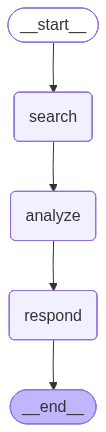

In [19]:
# 그래프 흐름: START → extract_info → validate → format_output → END
# extract_info: 텍스트에서 정보를 추출해요
# validate: 추출된 정보를 검증해요
# format_output: 결과를 포맷팅해요
display(Image(decomposed_app.get_graph().draw_mermaid_png()))

## 5. interrupt() 사용 규칙

`interrupt()`는 그래프 실행을 일시 중단하고 외부 입력을 기다려요.
올바르게 사용하려면 **3가지 규칙**을 지켜야 해요.

| 규칙 | 올바른 사용 | 잘못된 사용 |
|------|------------|------------|
| **위치** | 노드의 **처음**에 배치 | 노드 중간 또는 끝에 배치 |
| **예외 처리** | try/except **바깥**에 위치 | try/except **안**에 위치 |
| **순서 일관성** | resume 시 같은 순서 보장 | resume 시 다른 조건으로 건너뜀 |

> ⚠️ **자주 하는 실수**: `interrupt()`를 `try/except` 안에 넣으면 안 돼요. `interrupt()`는 내부적으로 예외를 던져서 실행을 중단하는 방식으로 동작해요. `try/except`가 이 예외를 잡아버리면 중단이 제대로 작동하지 않아요.

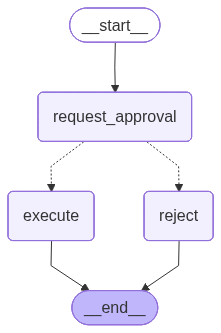

In [20]:
# ---------------------------------------------------
# interrupt() 올바른 사용 패턴 예시
# 규칙: 노드 처음에 배치, try/except 바깥에 위치
# ---------------------------------------------------
from langgraph.types import interrupt, Command

class ApprovalState(TypedDict):
    action: str         # 승인을 요청할 작업 설명
    approved: bool      # 승인 여부
    result: str         # 처리 결과

def request_approval(state: ApprovalState) -> dict:
    """올바른 interrupt() 사용 패턴이에요.
    
    규칙 1: 노드의 처음에 interrupt()를 배치해요
    규칙 2: try/except 바깥에 위치해요
    """
    # 올바른 위치: 노드의 처음에 interrupt()를 배치해요
    # 사람에게 작업 내용을 보여주고 승인을 기다려요
    decision = interrupt({
        "action_required": "approve",
        "description": state["action"],
        "options": ["yes", "no"]
    })

    # interrupt() 이후 코드는 resume 시 실행돼요
    approved = decision in ("yes", True, "approve")
    print(f"[승인 노드] 결정: {'승인' if approved else '거절'}")
    return {"approved": approved}


def execute_action(state: ApprovalState) -> dict:
    """승인된 작업을 실행해요."""
    print(f"[실행] 작업 수행: {state['action']}")
    return {"result": f"완료: {state['action']}"}


def reject_action(state: ApprovalState) -> dict:
    """거절된 작업을 처리해요."""
    print(f"[거절] 작업이 거절되었어요: {state['action']}")
    return {"result": f"거절됨: {state['action']}"}


def route_by_approval(state: ApprovalState) -> str:
    """승인 여부에 따라 분기해요."""
    return "execute" if state["approved"] else "reject"


# 그래프 구성
approval_graph = StateGraph(ApprovalState)
approval_graph.add_node("request_approval", request_approval)
approval_graph.add_node("execute", execute_action)
approval_graph.add_node("reject", reject_action)

approval_graph.add_edge(START, "request_approval")
approval_graph.add_conditional_edges(
    "request_approval",
    route_by_approval,
    {"execute": "execute", "reject": "reject"}
)
approval_graph.add_edge("execute", END)
approval_graph.add_edge("reject", END)

# interrupt()는 체크포인터가 있어야 작동해요
approval_checkpointer = InMemorySaver()
approval_app = approval_graph.compile(checkpointer=approval_checkpointer)

# interrupt() 패턴 그래프 구성 완료!
# 그래프 흐름: START → request_approval → execute_action → END
# request_approval 노드: interrupt()로 사람의 승인을 요청해요
# execute_action 노드: 승인된 작업을 실행해요
display(Image(approval_app.get_graph().draw_mermaid_png()))

In [21]:
# ---------------------------------------------------
# interrupt() + Command(resume=) 실행 흐름
# ---------------------------------------------------

approval_thread = str(uuid.uuid4())
approval_config = {"configurable": {"thread_id": approval_thread}}

# === 1단계: 그래프 실행 (interrupt에서 멈춰요) ===
result_1 = approval_app.invoke(
    {"action": "데이터베이스 레코드 삭제", "approved": False, "result": ""},
    approval_config
)
print(f"interrupt 시 반환된 상태: approved={result_1.get('approved')}, result='{result_1.get('result')}'")

print()
# === 2단계: 사람이 'yes'로 승인 ===
result_2 = approval_app.invoke(
    Command(resume="yes"),  # 승인 결정을 전달해요
    approval_config
)
print(f"최종 결과: {result_2.get('result')}")

interrupt 시 반환된 상태: approved=False, result=''

[승인 노드] 결정: 승인
[실행] 작업 수행: 데이터베이스 레코드 삭제
최종 결과: 완료: 데이터베이스 레코드 삭제


## 6. 종합 실습: 설계 원칙 적용

지금까지 배운 설계 원칙을 종합해서 간단한 콘텐츠 검수 시스템을 만들어볼게요.

> 🎯 **강의 포인트**: 실습 시 학생들에게 "이 설계에서 어떤 노드를 더 분해하거나 합칠 수 있을까요?"를 묻는 것이 좋아요. 정답은 없지만, 각자의 판단을 설명할 수 있어야 해요.

In [ ]:
# ============================================================
# 구현 예시: 콘텐츠 검수 시스템 설계 실습
# ============================================================
from typing import Literal, TypedDict
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
import uuid


class ContentReviewState(TypedDict):
    title: str
    content: str
    review_verdict: str      # "pass" 또는 "revise"
    improvement_suggestions: str
    editor_approved: bool
    published: bool
    result_message: str


def review_content(state: ContentReviewState) -> dict:
    """블로그 포스트를 검토해서 pass/revise를 판단해요."""
    response = model.invoke([
        SystemMessage(content="블로그 포스트를 검토하고 반드시 pass 또는 revise 중 하나만 답하세요."),
        HumanMessage(content=f"제목: {state['title']}\n본문: {state['content']}")
    ])
    raw = response.content.strip().lower()
    verdict = "revise" if "revise" in raw or "수정" in raw else "pass"
    print(f"[검토] 판정: {verdict}")
    return {"review_verdict": verdict}


def suggest_improvements(state: ContentReviewState) -> dict:
    """수정 필요 시 개선 제안을 생성해요."""
    response = model.invoke([
        SystemMessage(content="블로그 포스트 개선 제안을 한국어 bullet 3개로 작성하세요."),
        HumanMessage(content=f"제목: {state['title']}\n본문: {state['content']}")
    ])
    print("[개선 제안] 생성 완료")
    return {"improvement_suggestions": response.content}


def editor_review(state: ContentReviewState) -> dict:
    """편집자 승인 단계. interrupt는 노드의 처음에 배치해요."""
    decision = interrupt({
        "action": "editor_review",
        "title": state["title"],
        "verdict": state["review_verdict"],
        "suggestions": state["improvement_suggestions"],
        "message": "승인하려면 'approve', 거절하려면 피드백을 입력하세요.",
    })
    approved = decision in ("approve", "yes", "승인", True)
    return {"editor_approved": approved}


def publish_content(state: ContentReviewState) -> dict:
    """승인된 콘텐츠를 발행해요."""
    message = f"발행 완료: {state['title']}"
    print(f"[발행] {message}")
    return {"published": True, "result_message": message}


def reject_content(state: ContentReviewState) -> dict:
    """승인되지 않은 콘텐츠를 보류해요."""
    message = f"발행 보류: {state['title']}"
    print(f"[보류] {message}")
    return {"published": False, "result_message": message}


def route_after_review(state: ContentReviewState) -> Literal["suggest", "editor"]:
    return "suggest" if state["review_verdict"] == "revise" else "editor"


def route_after_editor(state: ContentReviewState) -> Literal["publish", "reject"]:
    return "publish" if state["editor_approved"] else "reject"


content_builder = StateGraph(ContentReviewState)
content_builder.add_node("review", review_content)
content_builder.add_node("suggest", suggest_improvements)
content_builder.add_node("editor", editor_review)
content_builder.add_node("publish", publish_content)
content_builder.add_node("reject", reject_content)

content_builder.add_edge(START, "review")
content_builder.add_conditional_edges("review", route_after_review, {"suggest": "suggest", "editor": "editor"})
content_builder.add_edge("suggest", "editor")
content_builder.add_conditional_edges("editor", route_after_editor, {"publish": "publish", "reject": "reject"})
content_builder.add_edge("publish", END)
content_builder.add_edge("reject", END)

content_app = content_builder.compile(checkpointer=InMemorySaver())

content_config = {"configurable": {"thread_id": str(uuid.uuid4())}}
sample_post = {
    "title": "LangGraph로 안정적인 에이전트 만들기",
    "content": "LangGraph는 상태, 체크포인터, 인터럽트를 사용해 복잡한 에이전트 흐름을 안정적으로 관리합니다.",
    "review_verdict": "",
    "improvement_suggestions": "",
    "editor_approved": False,
    "published": False,
    "result_message": "",
}

print("[1단계] 콘텐츠 검토 및 편집자 승인 대기")
partial_result = content_app.invoke(sample_post, content_config)
print("현재 판정:", partial_result.get("review_verdict"))
print("개선 제안:", partial_result.get("improvement_suggestions", "")[:200])

print("\n[2단계] 편집자가 승인하고 재개")
final_result = content_app.invoke(Command(resume="approve"), content_config)
print(final_result["result_message"])


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **5단계 방법론**: 워크플로우 매핑 → 타입 식별 → 상태 설계 → 노드 구현 → 엣지 연결 순서로 체계적으로 설계해요
- **상태 설계 원칙**: raw data를 저장하고 포맷된 텍스트는 금지해요. 리스트 필드는 reducer를 명시해요
- **노드 분해**: 단일 책임 원칙으로 노드를 작게 유지하면 스트리밍·체크포인트·디버깅이 쉬워져요
- **4가지 에러 유형**: Transient(RetryPolicy) / LLM-recoverable(루프백) / User-fixable(interrupt) / Unexpected(전파)
- **Command**: 상태 업데이트와 라우팅을 한 번에 처리할 때 사용해요
- **interrupt() 규칙**: 노드 처음에 배치, try/except 바깥에 위치, 순서 일관성 유지
- **안티패턴**: 포맷된 텍스트를 상태에 저장하거나, 하나의 노드가 너무 많은 역할을 하면 안 돼요

## 다음 노트북 예고

다음 `03-Reliability-Engineering.ipynb`에서는 **신뢰성 엔지니어링 5원칙 — Constrain · Inform · Verify · Correct · HITL**을 배워요. "에이전트가 실수했다"를 모델 탓이 아니라 주변 코드를 한 겹 덧댈 신호로 해석하는 사고틀이에요. 이후 04~13장에서 배울 middleware, memory, guardrails, testing이 모두 이 5가지 도구의 구체화예요.